<a href="https://colab.research.google.com/github/Dr-Isam-ALJAWARNEH/fds-project-space-time-clustering-for-aq/blob/main/Hypothesis_Space_Time_Clustering_of_Mobility_Patterns_and_Air_Quality_Hotspots_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **Project Title: Space-Time Clustering of Mobility Patterns and Air Quality Hotspots for Chicago**

## Hypothesis Testing (Statistical Validation)

| Type              | Statement                                                                 |
|-------------------|---------------------------------------------------------------------------|
| **Null Hypothesis (H₀)**     | There is **no relationship** between cluster assignments and pollution category. <br>Pollution is **randomly distributed** across clusters. |
| **Alternative Hypothesis (H₁)** | There **is a relationship** between clusters and pollution category. <br>Pollution categories **depend on** or are **structured by** cluster assignment. |

## interpertations
| Result                     | Meaning                                                                 |
|----------------------------|-------------------------------------------------------------------------|
| **p-value < 0.05**         | Reject H₀ → Clusters **do significantly relate** to pollution category |
| **p-value ≥ 0.05**         | Fail to reject H₀ → No significant pattern between clusters and pollution |
| **Higher Chi² Statistic**  | Stronger evidence that the clusters align with actual pollution levels  |

In [ ]:
from scipy.stats import chi2_contingency

In [ ]:
# Filter out noise points
valid_data = stratified_sampled[stratified_sampled['st_cluster'] != -1]
# Show the first few rows of valid clustered data
valid_data.head(10)

,geohash,time_bin,pickup_trip_count,dropoff_trip_count,total_trip_count,Temperature,Humidity,PM25,CO,latitude,...,index_right,community,pollution_category,kmeans_cluster,cluster_euc,cluster_man_0_5,cluster_man_0_8,time_hours,st_cluster,risk_level
0,dp3w71,2021-07-14 14:00:00,1.0,3.0,4.0,30.921408,60.996119,6.080133,0.371477,41.888123,...,25.0,AUSTIN,Low,2,0,0,0,588.0,0,Low Risk
2,dp3w71,2021-07-09 20:00:00,1.0,2.0,3.0,26.246685,41.545244,1.911035,0.135667,41.888123,...,25.0,AUSTIN,Low,2,0,0,0,474.0,1,Low Risk
4,dp3w71,2021-08-06 20:00:00,0.0,1.0,1.0,31.603889,51.009115,16.405541,0.456999,41.888123,...,25.0,AUSTIN,Medium,2,0,0,0,1146.0,12,Pollution Risk
6,dp3w71,2021-08-05 13:00:00,2.0,3.0,5.0,27.738425,57.503382,20.886163,0.533437,41.888123,...,25.0,AUSTIN,Medium,2,0,0,0,1115.0,2,Low Risk
7,dp3w71,2021-07-06 17:00:00,0.0,4.0,4.0,39.385230,42.654280,15.198884,0.180092,41.888123,...,25.0,AUSTIN,Medium,2,0,0,0,399.0,3,Pollution Risk
11,dp3w71,2021-07-27 20:00:00,2.0,4.0,6.0,34.111067,43.269602,12.816342,0.396735,41.888123,...,25.0,AUSTIN,Medium,2,0,0,0,906.0,4,Low Risk
13,dp3w71,2021-08-06 05:00:00,2.0,1.0,3.0,25.687199,49.626668,7.995104,0.236498,41.888123,...,25.0,AUSTIN,Low,2,0,0,0,1131.0,30,Low Risk
15,dp3w71,2021-10-06 05:00:00,1.0,0.0,1.0,19.088371,82.570995,14.364043,0.185142,41.888123,...,25.0,AUSTIN,Medium,2,0,0,0,2595.0,70,Pollution Risk
16,dp3w71,2021-10-04 13:00:00,0.0,2.0,2.0,20.805689,77.200190,10.439461,0.651030,41.888123,...,25.0,AUSTIN,Low,2,0,0,0,2555.0,41,Low Risk
17,dp3w71,2021-07-11 07:00:00,1.0,0.0,1.0,19.778964,84.755452,13.771104,0.154392,41.888123,...,25.0,AUSTIN,Medium,2,0,0,0,509.0,5,Low Risk


In [ ]:
stratified_sampled.columns

Index(['geohash', 'time_bin', 'pickup_trip_count', 'dropoff_trip_count',
       'total_trip_count', 'Temperature', 'Humidity', 'PM25', 'CO', 'latitude',
       'longitude', 'geometry', 'index_right', 'community',
       'pollution_category', 'kmeans_cluster', 'cluster_euc',
       'cluster_man_0_5', 'cluster_man_0_8', 'time_hours', 'st_cluster',
       'risk_level'],
      dtype='object')

In [ ]:
# ST-DBSCAN
st_valid = stratified_sampled[stratified_sampled['st_cluster'] != -1]
st_table = pd.crosstab(st_valid['st_cluster'], st_valid['pollution_category'])
chi2_st, p_st, dof_st, expected_st = chi2_contingency(st_table)

# KMeans
km_table = pd.crosstab(stratified_sampled['kmeans_cluster'], stratified_sampled['pollution_category'])
chi2_km, p_km, dof_km, expected_km = chi2_contingency(km_table)

# DBSCAN - assuming it's cluster_euc or similar (replace with correct one you used)
db_valid = stratified_sampled[stratified_sampled['cluster_euc'] != -1]
db_table = pd.crosstab(db_valid['cluster_euc'], db_valid['pollution_category'])
chi2_db, p_db, dof_db, expected_db = chi2_contingency(db_table)

In [ ]:
# 4. Results Summary
results = pd.DataFrame({
    'Method': ['KMeans', 'DBSCAN', 'ST-DBSCAN'],
    'Chi2 Statistic': [chi2_km, chi2_db, chi2_st],
    'p-value': [p_km, p_db, p_st],
    'Degrees of Freedom': [dof_km, dof_db, dof_st]
})

# Display the results
display(results)


,Method,Chi2 Statistic,p-value,Degrees of Freedom
0,KMeans,108.258502,4.718914e-21,6
1,DBSCAN,60.203684,4.251252e-10,8
2,ST-DBSCAN,6170.082110,0.000000e+00,1458


All three clustering methods show statistically significant relationships with pollution category.

ST-DBSCAN has the highest Chi² value, suggesting that it explains the most variability in the pollution distribution — best at identifying pollution-related patterns.

Very low p-values (< 0.05) for all indicate that we reject the null hypothesis: clustering and pollution category are not independent.

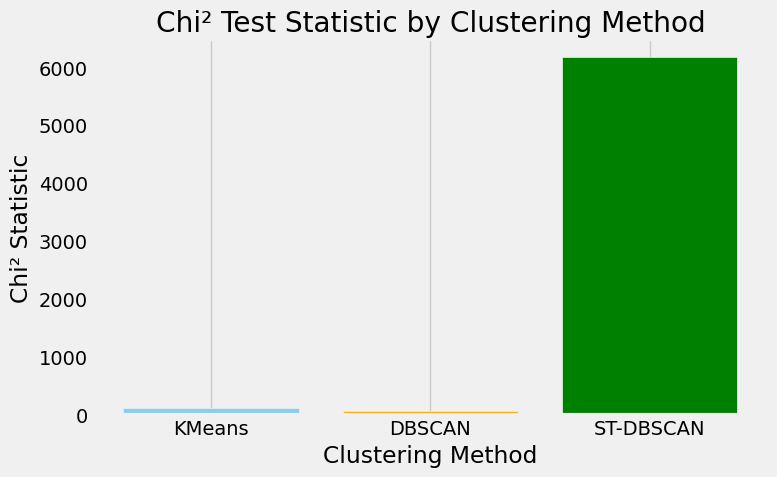

In [ ]:
# Bar chart of Chi² Statistics
plt.figure(figsize=(8, 5))
plt.bar(results['Method'], results['Chi2 Statistic'], color=['skyblue', 'orange', 'green'])
plt.title('Chi² Test Statistic by Clustering Method')
plt.xlabel('Clustering Method')
plt.ylabel('Chi² Statistic')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

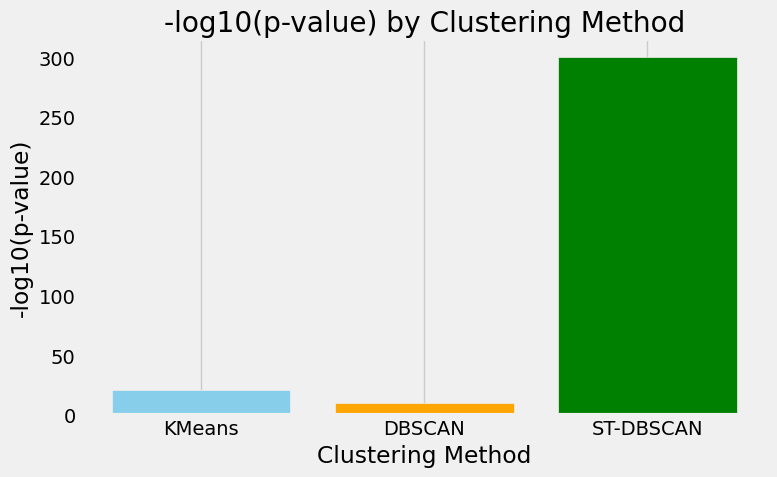

In [ ]:
# Bar chart of -log10(p-value) to highlight statistical significance
plt.figure(figsize=(8, 5))
p_log = -np.log10(results['p-value'].replace(0, 1e-300))  # Avoid -inf
plt.bar(results['Method'], p_log, color=['skyblue', 'orange', 'green'])
plt.title('-log10(p-value) by Clustering Method')
plt.xlabel('Clustering Method')
plt.ylabel('-log10(p-value)')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

This visually emphasize the strength of evidence (larger Chi² and smaller p-value = better).

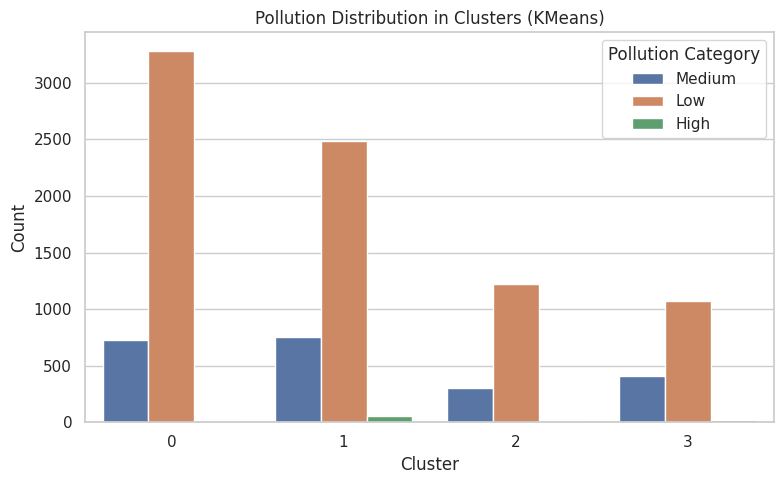

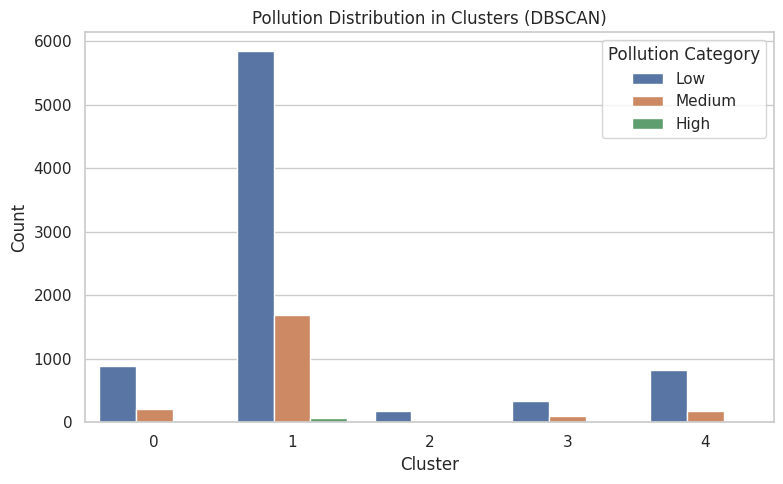

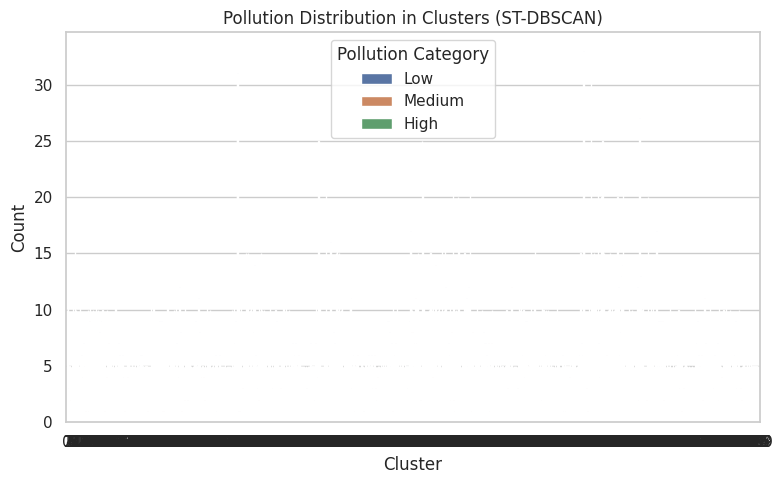

In [ ]:
# Set plot style
sns.set(style="whitegrid")

# Define plotting function
def plot_pollution_distribution(df, cluster_col, method_name):
    plt.figure(figsize=(8, 5))
    sns.countplot(data=df[df[cluster_col] != -1], x=cluster_col, hue='pollution_category')
    plt.title(f'Pollution Distribution in Clusters ({method_name})')
    plt.xlabel("Cluster")
    plt.ylabel("Count")
    plt.legend(title="Pollution Category")
    plt.tight_layout()
    plt.show()

# Plot for each method
plot_pollution_distribution(stratified_sampled, 'kmeans_cluster', 'KMeans')
plot_pollution_distribution(stratified_sampled, 'cluster_euc', 'DBSCAN')
plot_pollution_distribution(stratified_sampled, 'st_cluster', 'ST-DBSCAN')

<ipython-input-79-eef9a9f746be>:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=stratified_sampled[stratified_sampled['st_cluster'] != -1],


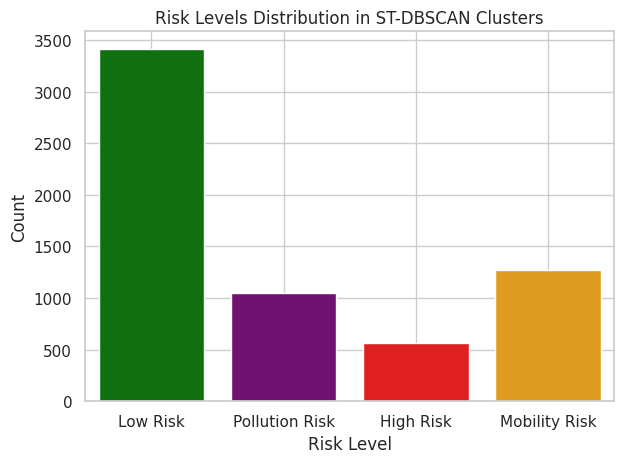

In [ ]:
sns.countplot(data=stratified_sampled[stratified_sampled['st_cluster'] != -1],
              x='risk_level',
              palette={'High Risk': 'red', 'Mobility Risk': 'orange', 'Pollution Risk': 'purple', 'Low Risk': 'green'})
plt.title("Risk Levels Distribution in ST-DBSCAN Clusters")
plt.xlabel("Risk Level")
plt.ylabel("Count")
plt.grid(True)
plt.tight_layout()
plt.show()


Description:
This bar chart shows the distribution of different risk levels assigned to data points after applying the ST-DBSCAN clustering algorithm. Each risk level—High Risk, Mobility Risk, Pollution Risk, and Low Risk—was derived from combining PM2.5 concentration and mobility volume using interquartile thresholds.

Interpretation:

The majority of clusters are categorized as Low Risk, suggesting many areas in the dataset exhibit neither high mobility nor severe air pollution.

A noticeable portion of clusters falls into Pollution Risk and Mobility Risk categories, indicating isolated issues in either mobility or air quality.

High Risk clusters are the least common, which is expected due to stricter criteria (both high PM2.5 and high mobility), but they are critical for urban planning as they represent potential hotspots.

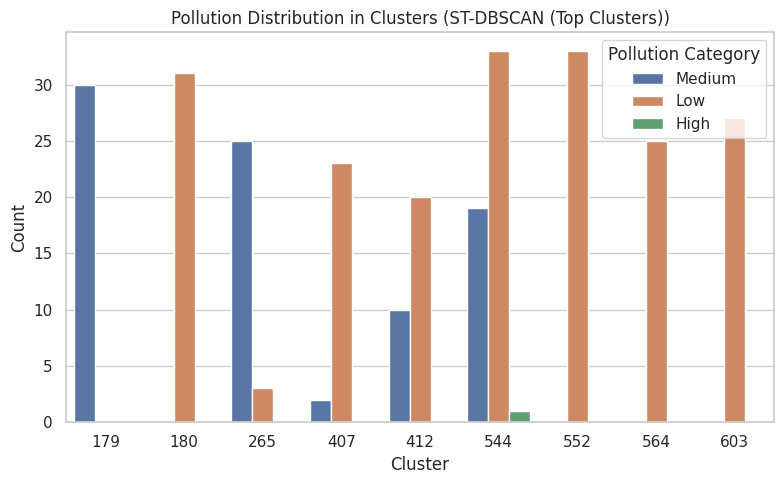

In [ ]:
# Find top 10 ST-DBSCAN clusters by frequency
top_clusters = stratified_sampled['st_cluster'].value_counts().head(10).index

# Filter data to only those clusters
filtered_data = stratified_sampled[stratified_sampled['st_cluster'].isin(top_clusters)]

# Plot
plot_pollution_distribution(filtered_data, 'st_cluster', 'ST-DBSCAN (Top Clusters)')


Description:
This chart visualizes the pollution category distribution (Low, Medium, High) within the top 10 most frequent ST-DBSCAN clusters. These clusters were selected based on the number of data points assigned to them.

Interpretation:

Most top clusters are dominated by Medium and Low pollution categories.

Only a few clusters show the presence of High pollution levels, indicating that while ST-DBSCAN captures dense spatial-temporal patterns, high PM2.5 conditions are more localized.

This visualization supports the idea that ST-DBSCAN is effective at uncovering localized variations, but the dominance of lower pollution may imply that either:

Air quality is generally within safe bounds, or

The clustering parameters should be adjusted to better capture pollution-specific clusters.